# Molecular Fingerprint Generation

In [1]:
import os
import sys
import pandas as pd
from pathlib import Path

# Print current working directory
print(f"Current working directory: {os.getcwd()}")

# Import the fingerprint generation module
from fp_generations import generate_fp

print("Successfully imported fingerprint generation module")

Current working directory: c:\Users\sabri\repositorios\Identification-of-Potent-HsDHODH-Inhibitors-via-Integrated-Computational-Pipeline
Successfully imported fingerprint generation module


## Set Input and Output Paths

In [13]:
# Define input and output paths
input_folder = 'input'
output_base = 'fp-gen'

# Create input folder if it doesn't exist
os.makedirs(input_folder, exist_ok=True)
print(f"Input folder: {os.path.abspath(input_folder)}")
print(f"Output base folder: {os.path.abspath(output_base)}")

# Check if the input SDF file exists
sdf_file = os.path.join(input_folder, 'HsDHODH-curated.sdf')
if os.path.exists(sdf_file):
    print(f"✓ Found input file: {sdf_file}")
else:
    print(f"⚠ Input file not found: {sdf_file}")
    print("Please ensure the HsDHODH-curated.sdf file is in the input folder")

Input folder: c:\Users\sabri\OneDrive\Documentos\UFG\project-BRICS\HsDHODH\QSAR-ML\ML-pycaret\input
Output base folder: c:\Users\sabri\OneDrive\Documentos\UFG\project-BRICS\HsDHODH\QSAR-ML\ML-pycaret\fp-gen
✓ Found input file: input\HsDHODH-curated.sdf


## Execute Fingerprint Generation

Run the generate_fp function with specified input and output parameters to create ECFP, FCFP, and MACCS fingerprints.

In [1]:
# Execute fingerprint generation
print("Starting fingerprint generation...")
print("This may take a few minutes depending on the dataset size...")

try:
    generate_fp(input_folder=input_folder, output_base=output_base)
    print("✓ Fingerprint generation completed successfully!")
except Exception as e:
    print(f"✗ Error during fingerprint generation: {str(e)}")
    print("Please check the input file and ensure all dependencies are installed")

Starting fingerprint generation...
This may take a few minutes depending on the dataset size...
✗ Error during fingerprint generation: name 'generate_fp' is not defined
Please check the input file and ensure all dependencies are installed


## Verify Generated Files

Check the output directories and list the generated CSV files to confirm successful fingerprint generation.

In [9]:
# Check generated directories and files
fingerprint_types = ['ecfp', 'fcfp', 'maccs']

print("Generated fingerprint files:")
print("=" * 50)

# Show directory structure
print(f"\nDirectory structure of {output_base}:")
for root, dirs, files in os.walk(output_base):
    level = root.replace(output_base, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:  # Show first 3 files
        print(f"{subindent}{file}")
    if len(files) > 3:
        print(f"{subindent}... and {len(files) - 3} more files")

Generated fingerprint files:

Directory structure of fp-gen:
fp-gen/
  ECFP/
    CPDS-withactvity-Luiza_ecfp_diam2_1024bits.csv
    CPDS-withactvity-Luiza_ecfp_diam2_2048bits.csv
    CPDS-withactvity-Luiza_ecfp_diam4_1024bits.csv
    ... and 9 more files
    diam6/
      ecfp_diam6_CPDS-withactvity-Luiza.csv
  FCFP/
    CPDS-withactvity-Luiza_fcfp_diam2_1024bits.csv
    CPDS-withactvity-Luiza_fcfp_diam2_2048bits.csv
    CPDS-withactvity-Luiza_fcfp_diam4_1024bits.csv
    ... and 9 more files
  MACCS/
    CPDS-withactvity-Luiza_maccs.csv
    HsDHODH-curated_maccs.csv


## Display Sample Results

Load and display sample data from the generated fingerprint files to verify the structure and content of the results.

In [5]:
# Display sample results from each fingerprint type
print("Sample fingerprint data:")
print("=" * 50)

for fp_type in fingerprint_types:
    fp_dir = os.path.join(output_base, fp_type)
    if os.path.exists(fp_dir):
        csv_files = [f for f in os.listdir(fp_dir) if f.endswith('.csv')]
        if csv_files:
            # Load the first CSV file found
            sample_file = os.path.join(fp_dir, csv_files[0])
            df = pd.read_csv(sample_file)
            
            print(f"\n{fp_type.upper()} Fingerprints ({csv_files[0]}):")
            print(f"Shape: {df.shape} (rows × columns)")
            print(f"Columns: SMILES, Outcome, + {df.shape[1]-2} fingerprint bits")
            
            # Display first few rows (only SMILES, Outcome, and first few fingerprint columns)
            display_cols = ['SMILES', 'Outcome'] + list(df.columns[2:7])  # First 5 fingerprint bits
            print(f"\nFirst 3 rows (showing first 5 fingerprint bits):")
            print(df[display_cols].head(3))
            
            # Show outcome distribution if available
            if 'Outcome' in df.columns and df['Outcome'].notna().any():
                print(f"\nOutcome distribution:")
                print(df['Outcome'].value_counts())
            else:
                print("\nNo outcome data available")
        else:
            print(f"\n⚠ No CSV files found in {fp_type} directory")
    else:
        print(f"\n⚠ {fp_type.upper()} directory not found")

Sample fingerprint data:

ECFP Fingerprints (HsDHODH-curated_ecfp_diam2_1024bits.csv):
Shape: (1792, 1026) (rows × columns)
Columns: SMILES, Outcome, + 1024 fingerprint bits

First 3 rows (showing first 5 fingerprint bits):
                                              SMILES  Outcome  0  1  2  3  4
0  C=c1[nH]n(-c2ccccc2)c(=O)c1=Cc1ccc(-c2cccc(C(=...      0.0  0  0  0  0  0
1  CCC(=O)C(C#N)C(=O)Nc1ccc(-c2ccc(F)nc2)c(C(=O)O...      1.0  0  1  0  0  0
2      O=C1C(O)=C(Nc2cccc(C(F)(F)F)c2)C(=O)c2ccccc21      1.0  0  0  0  0  0

Outcome distribution:
Outcome
1.0    1071
0.0     721
Name: count, dtype: int64

FCFP Fingerprints (HsDHODH-curated_fcfp_diam2_1024bits.csv):
Shape: (1792, 1026) (rows × columns)
Columns: SMILES, Outcome, + 1024 fingerprint bits

First 3 rows (showing first 5 fingerprint bits):
                                              SMILES  Outcome  0  1  2  3  4
0  C=c1[nH]n(-c2ccccc2)c(=O)c1=Cc1ccc(-c2cccc(C(=...      0.0  1  1  1  0  1
1  CCC(=O)C(C#N)C(=O)Nc1ccc(-c2ccc

## Summary

The fingerprint generation process is complete. The molecular fingerprints have been generated and saved in the following structure:

- **ECFP (Extended Connectivity Fingerprints)**: Saved in `fp-gen/ecfp/` with different diameters (2, 4, 6)
- **FCFP (Functional Connectivity Fingerprints)**: Saved in `fp-gen/fcfp/` with different diameters (2, 4, 6)  
- **MACCS Keys**: Saved in `fp-gen/maccs/`

Each CSV file contains:
- **SMILES**: Molecular structure representation
- **Outcome**: Target variable (if available in source data)
- **Fingerprint bits**: Binary features representing molecular substructures

These fingerprint files are now ready for machine learning model training and QSAR analysis.

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
import os
import pandas as pd

# Generate ECFP (Morgan) diameter 4 (radius=2) from the specified SDF file
# Requirements: RDKit installed in the environment (pip install rdkit-pypi or conda install -c conda-forge rdkit)


sdf_path = os.path.join('input', 'CPDS.sdf')
output_dir = os.path.join('fp-gen', 'ecfp', 'diam4')
os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(sdf_path):
    raise FileNotFoundError(f"SDF not found: {sdf_path}")

n_bits = 2048    # number of fingerprint bits (adjust if desired)
radius = 2       # radius=2 => diameter 4

suppl = Chem.SDMolSupplier(sdf_path)
rows = []

for mol in suppl:
    if mol is None:
        continue
    smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
    props = mol.GetPropsAsDict()
    
    # try to extract the molecule ID
    mol_id = None
    for key in ('FORMATTED_ID', 'ID', 'id', '_Name', 'Name', 'name', 'Compound_ID', 'compound_id'):
        if key in props:
            mol_id = props[key]
            break
    
    # try to find a common activity/target component column
    outcome = None
    for key in ('Outcome', 'OUTCOME', 'activity', 'Activity', 'ACTIVITY', 'value', 'Value', 'VALUE'):
        if key in props:
            outcome = props[key]
            break

    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    bitstring = fp.ToBitString()  # string with '0'/'1'
    bits = [int(b) for b in bitstring]

    row = {'ID': mol_id, 'SMILES': smiles, 'Outcome': outcome}
    # add columns bit_0 ... bit_{n_bits-1}
    for i, bit in enumerate(bits):
        row[f'bit_{i}'] = bit

    rows.append(row)

df = pd.DataFrame(rows)

out_file = os.path.join(output_dir, 'ecfp_diam4_CPDS.csv')
df.to_csv(out_file, index=False)
print(f"ECFP diam4 fingerprint generated for {len(df)} molecules -> {out_file}")


ECFP diam4 fingerprint generated for 10 molecules -> fp-gen\ecfp\diam4\ecfp_diam4_CPDS.csv


[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator
[15:53:23] DEPRECATION WARNING: please use MorganGenerator


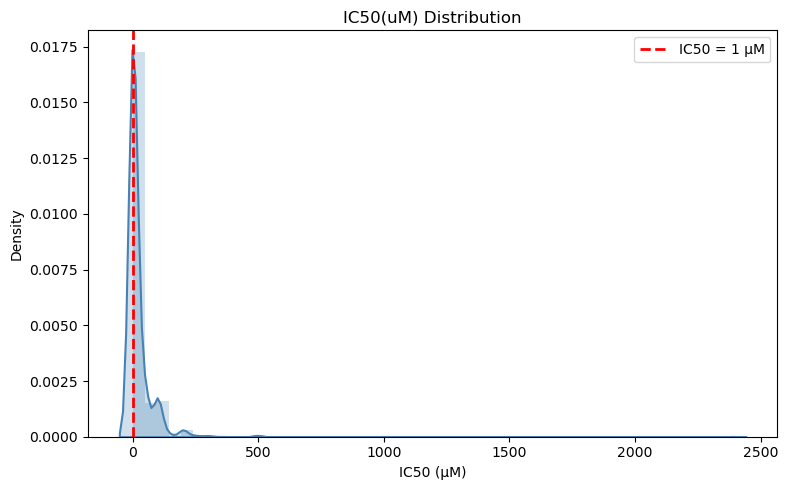

In [ ]:
# Plot KDE of the IC50(uM) column. Uses `vals` if available, otherwise tries to extract from the table.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get series of values
if "vals" in globals() and isinstance(vals, pd.Series):
    ic50_series = vals.dropna().astype(float)
else:
    # search for column containing 'ic50' in df_plot or data
    source = None
    if "df_plot" in globals():
        source = df_plot
    elif "data" in globals():
        source = data
    else:
        raise RuntimeError("No data source (vals, df_plot or data) found in the environment.")

    ic50_col = next((c for c in source.columns if "ic50" in c.lower()), None)
    if ic50_col is None:
        raise ValueError("Column containing 'ic50' not found in dataframe.")
    ic50_series = pd.to_numeric(source[ic50_col], errors="coerce").dropna().astype(float)

# Plot KDE (with semi-transparent histogram for context)
plt.figure(figsize=(8,5))
sns.histplot(ic50_series, bins=50, color='steelblue', alpha=0.25, stat='density', edgecolor=None)
sns.kdeplot(ic50_series, fill=True, color='steelblue', linewidth=1.5)

plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='IC50 = 1 µM')
plt.title("IC50(uM) Distribution")
plt.xlabel("IC50 (µM)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


## Features illustration

Bit 815 not active in this molecule.
Bit 699 not active in this molecule.
Bit 1563 not active in this molecule.
Bit 352 not active in this molecule.
Bit 1840 not active in this molecule.


[16:25:12] DEPRECATION WARNING: please use MorganGenerator


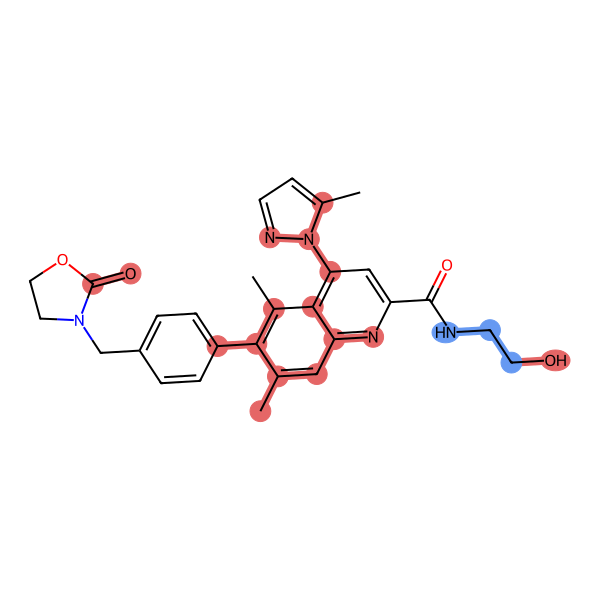

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def visualize_bits_with_atom_colors(smiles: str, bits_to_highlight=None, bit_color_map=None, radius: int = 3, nbits: int = 2048):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return "Invalid SMILES"

    # Generate fingerprint bit information
    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits, bitInfo=bit_info)

    highlight_atoms = set()
    highlight_bonds = set()

    # Default colors (R,G,B)
    default_red = (0.9, 0.4, 0.4)
    default_blue = (0.4, 0.6, 0.95)

    atom_colors = {}
    bond_colors = {}

    # Normalize input: allow either a simple list of bits, a dict grouping, or an explicit bit->color map
    # If user passed only a list, default to red
    if bit_color_map is None:
        bit_color_map = {}
        if isinstance(bits_to_highlight, list):
            for b in bits_to_highlight:
                bit_color_map[b] = default_red
        elif isinstance(bits_to_highlight, dict):
            # Accept grouping like {'red':[...], 'blue':[...]}
            for group_name, bits in bits_to_highlight.items():
                color = default_red if str(group_name).lower() == 'red' else default_blue
                for b in bits:
                    bit_color_map[b] = color

    # Now iterate through the bit->color map and collect atoms/bonds to highlight
    for bit_id, color in bit_color_map.items():
        if bit_id in bit_info:
            for atom_idx, r in bit_info[bit_id]:
                if r == 0:
                    highlight_atoms.add(atom_idx)
                    atom_colors[atom_idx] = color
                else:
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, r, atom_idx)
                    for b_idx in env:
                        bond = mol.GetBondWithIdx(b_idx)
                        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
                        highlight_bonds.add(b_idx)
                        highlight_atoms.update([a1, a2])
                        atom_colors[a1] = color
                        atom_colors[a2] = color
                        bond_colors[b_idx] = color
        else:
            print(f"Bit {bit_id} not active in this molecule.")

    # Drawing
    d = rdMolDraw2D.MolDraw2DSVG(600, 600)
    options = d.drawOptions()

    # Keep standard atom palette
    options.useBWAtomPalette = False
    # Fill the highlight area behind atom labels
    options.fillHighlights = True
    # Adjust highlight radius
    options.highlightRadius = 0.4

    rdMolDraw2D.PrepareAndDrawMolecule(d, mol, 
                                      highlightAtoms=list(highlight_atoms),
                                      highlightAtomColors=atom_colors,
                                      highlightBonds=list(highlight_bonds),
                                      highlightBondColors=bond_colors)
    d.FinishDrawing()
    return d.GetDrawingText()

# --- Run for your specific molecule ---
smiles_target = "Cc1cc2nc(C(=O)NCCO)cc(-n3nccc3C)c2c(C)c1-c1ccc(CN2CCOC2=O)cc1"
# Example: highlight some bits in red and others in blue
red_bits = [815, 314, 1747, 1391, 723, 222, 1018, 1852]
blue_bits = [699, 1563, 352, 1840, 1840, 667]
bit_color_map = {b: (0.9,0.4,0.4) for b in red_bits}
bit_color_map.update({b: (0.4,0.6,0.95) for b in blue_bits})

svg_image = visualize_bits_with_atom_colors(smiles_target, bit_color_map=bit_color_map)
SVG(svg_image)